# Load data, imports, installs

In [ ]:
!pip install krippendorff

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import cohen_kappa_score
from itertools import combinations
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import krippendorff


In [ ]:
!unzip "/content/annotation_output.zip"

Archive:  /content/annotation_output.zip
   creating: annotation_output/
  inflating: annotation_output/all_annotations.csv  
  inflating: annotation_output/self_consistency_duplicates.csv  


In [ ]:
all_annot=pd.read_csv("/content/annotation_output/all_annotations.csv")
consist=pd.read_csv("/content/annotation_output/self_consistency_duplicates.csv")

# Consistency check

| Positive | Negative | No Reinforcement | Final |
|----------|----------|---------------|----------------------|
| ✗        | ✗        | ✗             | No (0)  |
| ✓        | ✗        | ✗             | Positive  (1)           |
| ✗        | ✓        | ✗             | Negative (2)            |
| ✗        | ✗        | ✓             | No      (0)     |
| ✓        | ✓        | ✗             | Both (3)|
| ✓        | ✗        | ✓             | Positive (1) |
| ✗        | ✓        | ✓             | Negative (2) |
| ✓        | ✓        | ✓             | Both (3) |

In [ ]:
def map_final(row):
    p = row["positive_reinforcement"]
    n = row["negative_reinforcement"]
    nr = row["no_reinforcement"]

    # transform according to the table above
    if p and n:
        return "Both"
    if p:
        return "Positive"
    if n:
        return "Negative"
    if nr:
        return "No"
    return "No"


consist["Final"] = consist.apply(map_final, axis=1)

label_map = {
    "No": 0,
    "Positive": 1,
    "Negative": 2,
    "Both": 3
}

consist["Final_numeric"] = consist["Final"].map(label_map)


# print(consist[
#     ["annotator",
#      "conv_id",
#      "positive_reinforcement",
#      "negative_reinforcement",
#      "no_reinforcement",
#      "Final",
#      "Final_numeric"]
# ].head())


# print("\nLabel distribution:")
# print(consist["Final"].value_counts())

In [ ]:
consist

,annotator,conv_id,discussion,data_malformation,rationale,positive_reinforcement,negative_reinforcement,no_reinforcement,Final,Final_numeric
0,A1,011632cb01558cc5b2465eeca35a9ff6,"User Mpogoda:\nAs a frequent traveler, I would...",0.0,"one participant introduces hostile, dismissive...",3,4,1,Both,3
1,A1,011632cb01558cc5b2465eeca35a9ff6,User Regina:\nIt seems that so many people on ...,0,"reasoned, experience-based arguments",4,2,2,Both,3
2,A1,021115%20American%20Decline,"User John Donvan:\nThank you, Jim Rickards. An...",0.0,0,1,1,3,Both,3
3,A1,021115%20American%20Decline,User John Donvan:\nSo you're just saying that ...,0,There is a constructive dialogue,4,1,2,Both,3
4,A1,021313%20genetic%20engineering,User John Donvan:\nIn a world-- in a world whe...,0.0,0,0,0,0,No,0
...,...,...,...,...,...,...,...,...,...,...
2677,A11,religion,User Matthew Chapman:\nHow can you be angry wi...,0,0,1,1,5,Both,3
2678,A11,terrorists-enemy,User Robert Rosenkranz:\nTonight’s resolution ...,0,0,1,1,5,Both,3
2679,A11,terrorists-enemy,User Marc Thiessen:\nThe inaugural address of ...,0,0,1,1,5,Both,3
2680,A11,tired-poor,"User Robert Rosenkranz:\nWell, thank you very ...",0,0,1,1,5,Both,3


In [ ]:
# extract duplicate rows
dup_df = consist[consist.duplicated(
    subset=["annotator", "discussion"],
    keep=False
)].copy()

# order them into pairs/passes
dup_df = dup_df.sort_values(["annotator", "discussion"])
dup_df["pass_id"] = dup_df.groupby(
    ["annotator", "discussion"]
).cumcount() + 1

dup_df = dup_df[dup_df["pass_id"].isin([1, 2])]

pass1 = dup_df[dup_df["pass_id"] == 1][
    ["annotator", "discussion", "Final_numeric"]
].rename(columns={"Final_numeric": "pass_1"})

pass2 = dup_df[dup_df["pass_id"] == 2][
    ["annotator", "discussion", "Final_numeric"]
].rename(columns={"Final_numeric": "pass_2"})

dup_pairs = pass1.merge(
    pass2,
    on=["annotator", "discussion"],
    how="inner"
)


# compute iaa
dup_pairs["agreement"] = (
    dup_pairs["pass_1"] == dup_pairs["pass_2"]
).astype(int)

# annotator_intra = dup_pairs.groupby("annotator")["agreement"].mean().reset_index()


In [ ]:
annotator_pct_agreement = (
    dup_pairs.groupby("annotator")["agreement"]
    .mean()
    .reset_index(name="pct_agreement")
)

annotator_pct_agreement["pct_agreement"] *= 100

print(annotator_pct_agreement)

   annotator  pct_agreement
0         A1      55.555556
1        A10     100.000000
2        A11     100.000000
3         A2     100.000000
4         A3      66.666667
5         A4      88.888889
6         A5     100.000000
7         A6     100.000000
8         A7     100.000000
9         A8     100.000000
10        A9     100.000000


# Frequencies

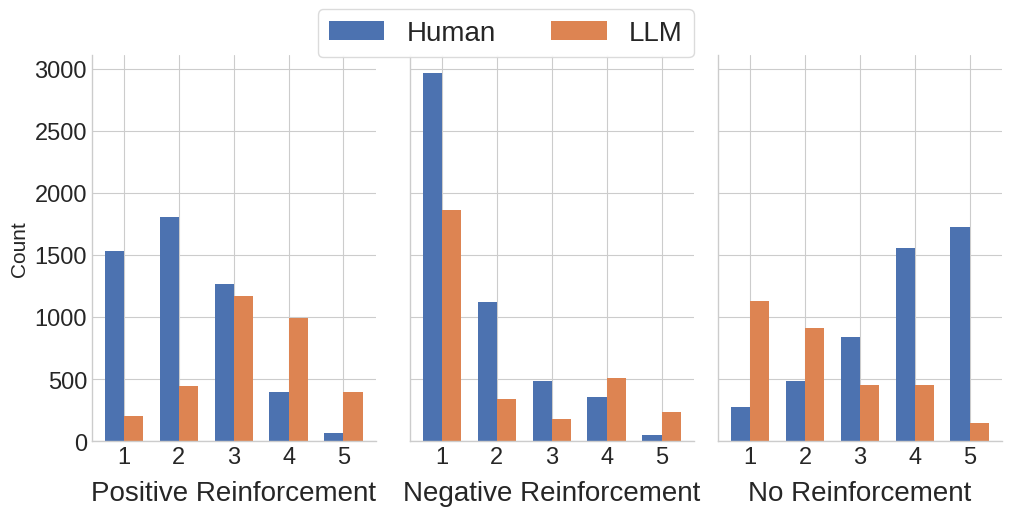

In [ ]:
categories = [
    "positive_reinforcement",
    "negative_reinforcement",
    "no_reinforcement"
]

plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(
    1, len(categories),
    figsize=(10, 4.6),
    sharey=True,
    constrained_layout=True
)

colors = {
    "Human": "#4C72B0",
    "LLM": "#DD8452"
}

for ax, cat in zip(axes, categories):

    # ---------------- HUMAN ----------------
    human_cols = [
        c for c in all_annot.columns
        if re.match(rf"A\d+_{cat}$", c) and not c.startswith("A1_")
    ]

    human_vals = (
        all_annot[human_cols]
        .to_numpy()
        .ravel()
    )

    human_vals = pd.Series(human_vals).dropna()

    # remove 0s
    human_vals = human_vals[human_vals != 0]

    # ---------------- llm ----------------
    machine_cols = [
        c for c in all_annot.columns
        if cat in c and not re.match(r"A\d+_", c)
    ]

    machine_vals = (
        all_annot[machine_cols]
        .to_numpy()
        .ravel()
    )

    machine_vals = pd.Series(machine_vals).dropna()

    # remove 0s
    machine_vals = machine_vals[machine_vals != 0]

    # ---------------- COUNTS ----------------
    x = [1, 2, 3, 4, 5]

    human_counts = human_vals.value_counts().reindex(x, fill_value=0)
    machine_counts = machine_vals.value_counts().reindex(x, fill_value=0)

    width = 0.35

    ax.bar(
        [v - width/2 for v in x],
        human_counts.values,
        width=width,
        color=colors["Human"],
        label="Human"
    )

    ax.bar(
        [v + width/2 for v in x],
        machine_counts.values,
        width=width,
        color=colors["LLM"],
        label="LLM"
    )

    # x-axis only 1–5
    ax.set_xticks(x)

    ax.text(
        0.5,
        -0.10,
        cat.replace("_", " ").title(),
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=20
    )


    ax.set_xlabel("")
    ax.tick_params(axis="both", labelsize=17)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


axes[0].set_ylabel("Count", fontsize=15)

# ---------------- LEGEND ----------------
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    edgecolor="0.85",
    fontsize=20,
    bbox_to_anchor=(0.5, 1.12)
)

plt.show()

In [ ]:
# remove A1
annotators = [f"A{i}" for i in range(2, 12)]


llm_annotators = [
    "Qwen32b_dual_interventions.md",
    "Qwen7b_dual_interventions.md",
    "Llama8b_dual_interventions.md",
    "Olmo7b_dual_interventions.md",
    "Olmo32b_dual_interventions.md",
    "Llama70b_dual_interventions.md"
]

# combine all annotators
all_annotators = annotators + llm_annotators


def map_labels(pos, neg, no):
    """
    Mapping:
    0 = No
    1 = Positive
    2 = Negative
    3 = Both
    """

    # thresholding
    pos = pos >= 3
    neg = neg >= 3
    no  = no >= 3

    # both positive and negative
    if pos and neg:
        return 3

    # positive cases
    if pos:
        return 1

    # negative cases
    if neg:
        return 2

    # no reinforcement or all false
    return 0


# create final labels
for ann in all_annotators:

    pos_col = f"{ann}_positive_reinforcement"
    neg_col = f"{ann}_negative_reinforcement"
    no_col  = f"{ann}_no_reinforcement"

    new_col = f"{ann}_final_label"

    # skip if columns don't exist
    required_cols = [pos_col, neg_col, no_col]

    if all(col in all_annot.columns for col in required_cols):

        all_annot[new_col] = all_annot.apply(
            lambda row: map_labels(
                row[pos_col],
                row[neg_col],
                row[no_col]
            ),
            axis=1
        )

# inspect
final_cols = [c for c in all_annot.columns if c.endswith("_final_label")]

print(final_cols)

all_annot[final_cols].head(10)

['A2_final_label', 'A3_final_label', 'A4_final_label', 'A5_final_label', 'A6_final_label', 'A7_final_label', 'A8_final_label', 'A9_final_label', 'A10_final_label', 'A11_final_label', 'Qwen32b_dual_interventions.md_final_label', 'Qwen7b_dual_interventions.md_final_label', 'Llama8b_dual_interventions.md_final_label', 'Olmo7b_dual_interventions.md_final_label', 'Olmo32b_dual_interventions.md_final_label', 'Llama70b_dual_interventions.md_final_label']


,A2_final_label,A3_final_label,A4_final_label,A5_final_label,A6_final_label,A7_final_label,A8_final_label,A9_final_label,A10_final_label,A11_final_label,Qwen32b_dual_interventions.md_final_label,Qwen7b_dual_interventions.md_final_label,Llama8b_dual_interventions.md_final_label,Olmo7b_dual_interventions.md_final_label,Olmo32b_dual_interventions.md_final_label,Llama70b_dual_interventions.md_final_label
0,0,0,1,0,1,1,0,0,1,0,1,3,1,1,1,1
1,0,0,0,0,0,0,1,0,0,2,1,2,1,1,1,1
2,2,1,2,1,1,0,2,1,0,0,1,2,1,1,1,0
3,0,1,0,1,0,0,1,1,0,0,1,2,1,1,1,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,2,0,1,0,0,1,0,0,0,1,3,1,1,1,0
6,1,1,1,1,1,1,0,0,0,0,1,3,1,1,1,1
7,0,1,0,0,0,0,1,0,0,0,1,3,1,1,0,1
8,0,0,0,0,1,1,0,0,0,0,1,3,1,1,1,1
9,0,1,2,0,0,1,0,0,0,0,1,3,1,1,1,1


In [ ]:
# include both human + LLM final label columns
final_cols = [
    f"{a}_final_label"
    for a in all_annotators
    if f"{a}_final_label" in all_annot.columns
]

# percentage frequency table
freq_pct = pd.DataFrame({
    c: all_annot[c].value_counts(normalize=True).sort_index() * 100
    for c in final_cols
}).reindex([0, 1, 2, 3]).fillna(0)

# readable row labels
freq_pct.index = ["No", "Positive", "Negative", "Both"]

# transpose for plotting
plot_df = freq_pct.T

# cleaner names
plot_df.index = (
    plot_df.index
        .str.replace("_final_label", "", regex=False)
        .str.replace("_dual_interventions.md", "", regex=False)
)

# inspect
plot_df.head()

,No,Positive,Negative,Both
A2,76.699029,5.825243,14.424411,3.051318
A3,42.441054,34.119279,23.300971,0.138696
A4,68.515950,18.307906,11.789182,1.386963
A5,74.479889,20.110957,4.576976,0.832178
A6,59.361997,24.826630,14.563107,1.248266


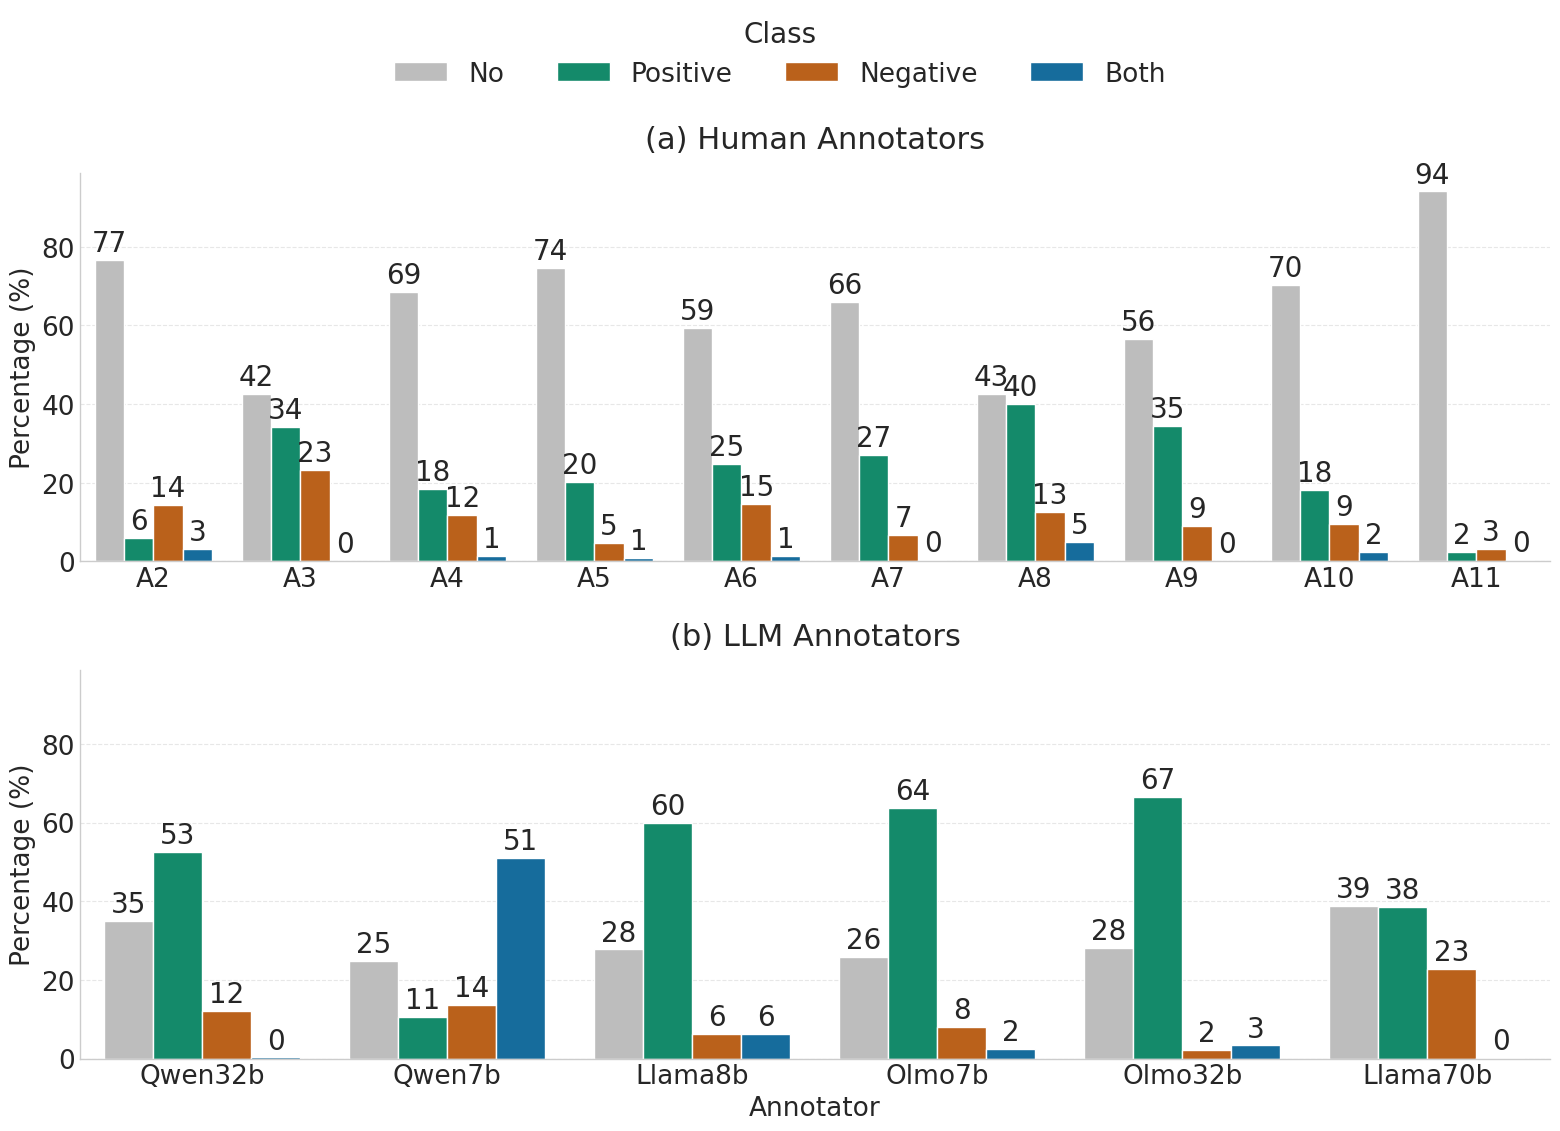

In [ ]:
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 20,
    "axes.titlesize": 22,
    "axes.labelsize": 19,
    "xtick.labelsize": 19,
    "ytick.labelsize": 19,
    "legend.fontsize": 19
})

sns.set_style("whitegrid", {
    "grid.color": "#BDBDBD",
    "grid.linestyle": "-",
    "grid.linewidth": 1.1
})

plot_df = freq_pct.copy()

plot_df.index = ["No", "Positive", "Negative", "Both"]

plot_df = (
    plot_df.T
    .reset_index()
    .melt(
        id_vars="index",
        var_name="Class",
        value_name="Percentage"
    )
    .rename(columns={"index": "Annotator"})
)


plot_df["Annotator"] = (
    plot_df["Annotator"]
        .str.replace("_final_label", "", regex=False)
        .str.replace("_dual_interventions.md", "", regex=False)
)

human_annotators = [f"A{i}" for i in range(2, 12)]

model_annotators = [
    "Qwen32b",
    "Qwen7b",
    "Llama8b",
    "Olmo7b",
    "Olmo32b",
    "Llama70b"
]

human_df = plot_df[
    plot_df["Annotator"].isin(human_annotators)
].copy()

model_df = plot_df[
    plot_df["Annotator"].isin(model_annotators)
].copy()

# preserve order
human_df["Annotator"] = pd.Categorical(
    human_df["Annotator"],
    categories=human_annotators,
    ordered=True
)

model_df["Annotator"] = pd.Categorical(
    model_df["Annotator"],
    categories=model_annotators,
    ordered=True
)


palette = [
    "#BDBDBD",  # No
    "#009E73",  # Positive
    "#D55E00",  # Negative
    "#0072B2"   # Both
]

fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 11),
    sharey=True
)


ax1 = axes[0]

sns.barplot(
    data=human_df,
    x="Annotator",
    y="Percentage",
    hue="Class",
    palette=palette,
    edgecolor="white",
    ax=ax1
)

ax1.set_title("(a) Human Annotators", pad=18)
ax1.set_xlabel("")
ax1.set_ylabel("Percentage (%)")

ax1.grid(axis="y", linestyle="--", alpha=0.35)
ax1.grid(axis="x", visible=False)

# labels
for container in ax1.containers:
    labels = [
        f"{int(round(v))}" if v > 0 else ""
        for v in container.datavalues
    ]

    ax1.bar_label(
        container,
        labels=labels,
        fontsize=20,
        padding=2
    )

ax2 = axes[1]

sns.barplot(
    data=model_df,
    x="Annotator",
    y="Percentage",
    hue="Class",
    palette=palette,
    edgecolor="white",
    ax=ax2
)

ax2.set_title("(b) LLM Annotators", pad=18)
ax2.set_xlabel("Annotator")
ax2.set_ylabel("Percentage (%)")

ax2.grid(axis="y", linestyle="--", alpha=0.35)
ax2.grid(axis="x", visible=False)

# labels
for container in ax2.containers:
    labels = [
        f"{int(round(v))}" if v > 0 else ""
        for v in container.datavalues
    ]

    ax2.bar_label(
        container,
        labels=labels,
        fontsize=20,
        padding=2
    )


handles, labels = ax1.get_legend_handles_labels()

ax1.legend_.remove()
ax2.legend_.remove()

fig.legend(
    handles,
    labels,
    title="Class",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=4,
    frameon=False
)


sns.despine()

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "annotator_distribution.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

Per dataset

In [ ]:
# per dataset
df_long = all_annot[["dataset"] + final_cols].melt(
    id_vars="dataset",
    value_vars=final_cols,
    var_name="annotator",
    value_name="label"
)

In [ ]:
# counts per (dataset, label)
tmp = df_long.value_counts(["dataset", "label"]).reset_index(name="count")

# convert to percentages per dataset
tmp["Percentage"] = tmp["count"] / tmp.groupby("dataset")["count"].transform("sum") * 100

In [ ]:
dataset_plot = tmp.pivot(
    index="dataset",
    columns="label",
    values="Percentage"
).fillna(0)

dataset_plot.columns = ["No", "Positive", "Negative", "Both"]

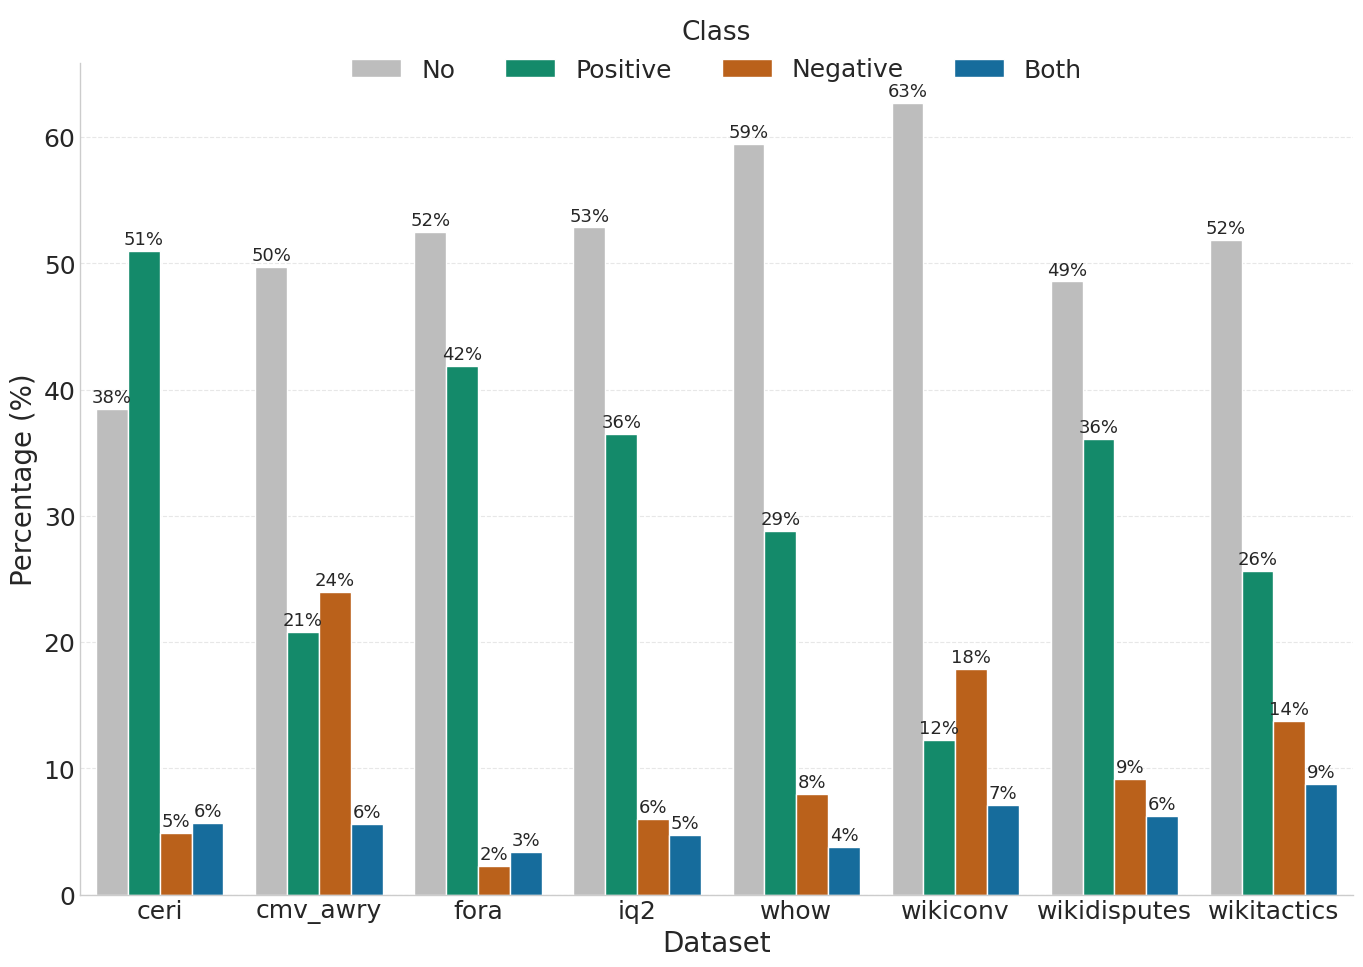

In [ ]:

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 19,
    "axes.titlesize": 23,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})

sns.set_style("whitegrid", {
    "grid.color": "#BDBDBD",
    "grid.linestyle": "-",
    "grid.linewidth": 1.2
})

# melt for seaborn
df_plot = dataset_plot.reset_index().melt(
    id_vars="dataset",
    var_name="Class",
    value_name="Percentage"
)

palette = ["#BDBDBD", "#009E73", "#D55E00", "#0072B2"]

plt.figure(figsize=(14, 10))

ax = sns.barplot(
    data=df_plot,
    x="dataset",
    y="Percentage",
    hue="Class",
    palette=palette,
    edgecolor="white"
)

# annotations
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{int(round(v))}%" if v > 0 else "" for v in container.datavalues],
        fontsize=13,
        padding=2
    )

ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Dataset")

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.grid(axis="x", visible=False)

sns.despine()

plt.legend(
    title="Class",
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=4
)

plt.tight_layout()

plt.show()

# IAA and correlations

In [ ]:
# Replace blanks coded as 0 with NaN: they will be excluded from all calculations

df_clean = all_annot.replace(0, np.nan)

# defining the two groups
human_annotators = [f"A{i}" for i in range(2, 11)]

models = [
    "Qwen32b_dual_interventions.md",
    "Qwen7b_dual_interventions.md",
    "Llama8b_dual_interventions.md",
    "Llama70b_dual_interventions.md",
    "Olmo32b_dual_interventions.md",
    "Olmo7b_dual_interventions.md",
    "Qwen32b_single_response",
    "Qwen7b_single_response",
    "Llama8b_single_response",
    "Llama70b_single_response",
    "Olmo32b_single_response",
    "Olmo7b_single_response"
]

classes = [
    "positive_reinforcement",
    "negative_reinforcement",
    "no_reinforcement"
]


def get_cols(group, cls):

    cols = []

    for g in group:

        col_name = f"{g}_{cls}"

        if col_name in df_clean.columns:
            cols.append(col_name)

    return cols


# Pairwise metrics
def pairwise_metrics(cols):

    pairwise = []

    for c1, c2 in combinations(cols, 2):

        pair_df = df_clean[[c1, c2]].dropna()

        if len(pair_df) < 2:
            continue

        x = pair_df[c1].astype(float)
        y = pair_df[c2].astype(float)

        pearson_r, _ = pearsonr(x, y)
        spearman_rho, _ = spearmanr(x, y)
        kappa = cohen_kappa_score(x, y, weights="quadratic")

        pairwise.append({
            "rater_1": c1,
            "rater_2": c2,
            "pearson_r": pearson_r,
            "spearman_rho": spearman_rho,
            "weighted_kappa": kappa,
            "n_samples": len(pair_df)
        })

    return pd.DataFrame(pairwise)

# Krippendorff's alpha
def krippendorff_alpha(cols):

    if len(cols) < 2:
        return None


    data = (
        df_clean[cols]
        .astype(float)
        .to_numpy()
        .T
    )

    return krippendorff.alpha(
        reliability_data=data,
        level_of_measurement="ordinal"
    )

# compute all metrics
results = []

groups = {
    "humans": human_annotators,
    "models": models,
    "humans+models": human_annotators + models
}

for group_name, group_list in groups.items():

    for cls in classes:

        cols = get_cols(group_list, cls)

        if len(cols) < 2:
            continue

        pairwise_df = pairwise_metrics(cols)

        if not pairwise_df.empty:

            mean_pearson = pairwise_df["pearson_r"].mean()
            mean_spearman = pairwise_df["spearman_rho"].mean()
            mean_kappa = pairwise_df["weighted_kappa"].mean()
            mean_n = pairwise_df["n_samples"].mean()

        else:

            mean_pearson = None
            mean_spearman = None
            mean_kappa = None
            mean_n = None

        alpha = krippendorff_alpha(cols)

        results.append({
            "group": group_name,
            "class": cls,
            "pearson_r_mean": mean_pearson,
            "spearman_rho_mean": mean_spearman,
            "weighted_kappa_mean": mean_kappa,
            "krippendorff_alpha": alpha,
            "avg_valid_samples": mean_n
        })


final_results_df = pd.DataFrame(results)

print(final_results_df.round(2))

           group                   class  pearson_r_mean  spearman_rho_mean  \
0         humans  positive_reinforcement            0.18               0.18   
1         humans  negative_reinforcement            0.41               0.35   
2         humans        no_reinforcement            0.14               0.14   
3         models  positive_reinforcement            0.44               0.42   
4         models  negative_reinforcement            0.56               0.53   
5         models        no_reinforcement            0.13               0.13   
6  humans+models  positive_reinforcement            0.23               0.22   
7  humans+models  negative_reinforcement            0.38               0.36   
8  humans+models        no_reinforcement            0.09               0.09   

   weighted_kappa_mean  krippendorff_alpha  avg_valid_samples  
0                 0.15                0.16             429.11  
1                 0.33                0.32             411.17  
2                

In [ ]:
# Show full text for any column
pd.set_option('display.max_colwidth', None)

# Now display your cell
print(all_annot.loc[706]['discussion'])

User Hannah Rosin:
Or you could end up in a situation where it gets worse and worse and worse and the income-- you know, you have a sort of little upper class of people that these guys are talking about that consists of Bill Gates and maybe the people in this audience and not very many more people and everybody else is sort of struggling with the women holding the bag, it's called the last bag theory where the woman because she's raising the child is also going to school and making the money and the men are just sort of struggling and out of work.

User Dan Abrams:
I would just add to that, the bigger problem I think for men is the unwillingness to take what have been viewed as classically female jobs, teachers, nurses, or healthcare professionals, et cetera, and that's the area where if you want to talk about how do we make this better, how do we end-- how do we reverse men being finished, which they are-- how do we reverse that? Well, part of it has got to be that men are going to ha

In [ ]:

# HUMAN AND LLM FINAL LABEL COLUMNS
human_final_cols = [f"A{i}_final_label" for i in range(2, 12)]
llm_final_cols = [
    "Qwen32b_dual_interventions.md_final_label",
    "Qwen7b_dual_interventions.md_final_label",
    "Llama8b_dual_interventions.md_final_label",
    "Olmo7b_dual_interventions.md_final_label",
    "Olmo32b_dual_interventions.md_final_label",
    "Llama70b_dual_interventions.md_final_label"
]

# EXTRACT HUMAN AND LLM LABELS
human_labels = all_annot[human_final_cols]
llm_labels = all_annot[llm_final_cols]

# COMPUTE ROW-WISE LLM MODE (numeric)
llm_mode_df = llm_labels.mode(axis=1)
llm_mode_series = llm_mode_df[0]  # pick first mode if tie

# ROW-WISE LLM AGREEMENT (numeric)
llm_agreement = llm_labels.apply(
    lambda row: (row == llm_mode_series.loc[row.name]).sum() / len(row),
    axis=1
)

# IDENTIFY COMMENTS WHERE NO HUMAN AGREES
human_agree = human_labels.eq(llm_mode_series, axis=0).any(axis=1)
no_human_agree = ~human_agree

# FILTER EXTREME CASES
extreme_cases = all_annot.loc[no_human_agree, llm_final_cols + human_final_cols].copy()
extreme_cases['LLM_Mode'] = llm_mode_series[no_human_agree]
extreme_cases['LLM_Agreement'] = llm_agreement[no_human_agree]

# SORT BY LLM AGREEMENT
extreme_cases = extreme_cases.sort_values('LLM_Agreement', ascending=False)

# NOW map numeric labels to readable strings
label_map = {0: "No", 1: "Positive", 2: "Negative", 3: "Both"}
extreme_cases_readable = extreme_cases.copy()
for col in extreme_cases_readable.columns:
    if col not in ['LLM_Agreement']:  # skip numeric column
        extreme_cases_readable[col] = extreme_cases_readable[col].map(label_map)

# SHOW TOP 10
pd.set_option('display.max_columns', None)
print(extreme_cases_readable.head(10))

    Qwen32b_dual_interventions.md_final_label  \
706                                  Positive   
582                                  Positive   
520                                  Positive   
459                                  Positive   
661                                  Positive   
620                                  Negative   
551                                  Positive   
33                                   Positive   
648                                  Positive   
619                                  Positive   

    Qwen7b_dual_interventions.md_final_label  \
706                                     Both   
582                                     Both   
520                                     Both   
459                                     Both   
661                                     Both   
620                                 Negative   
551                                     Both   
33                                      Both   
648                         

Total extreme cases (no human agrees with LLM mode): 36


/tmp/ipykernel_2662/492413861.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_numeric = plot_top[all_cols].replace(label_to_num)


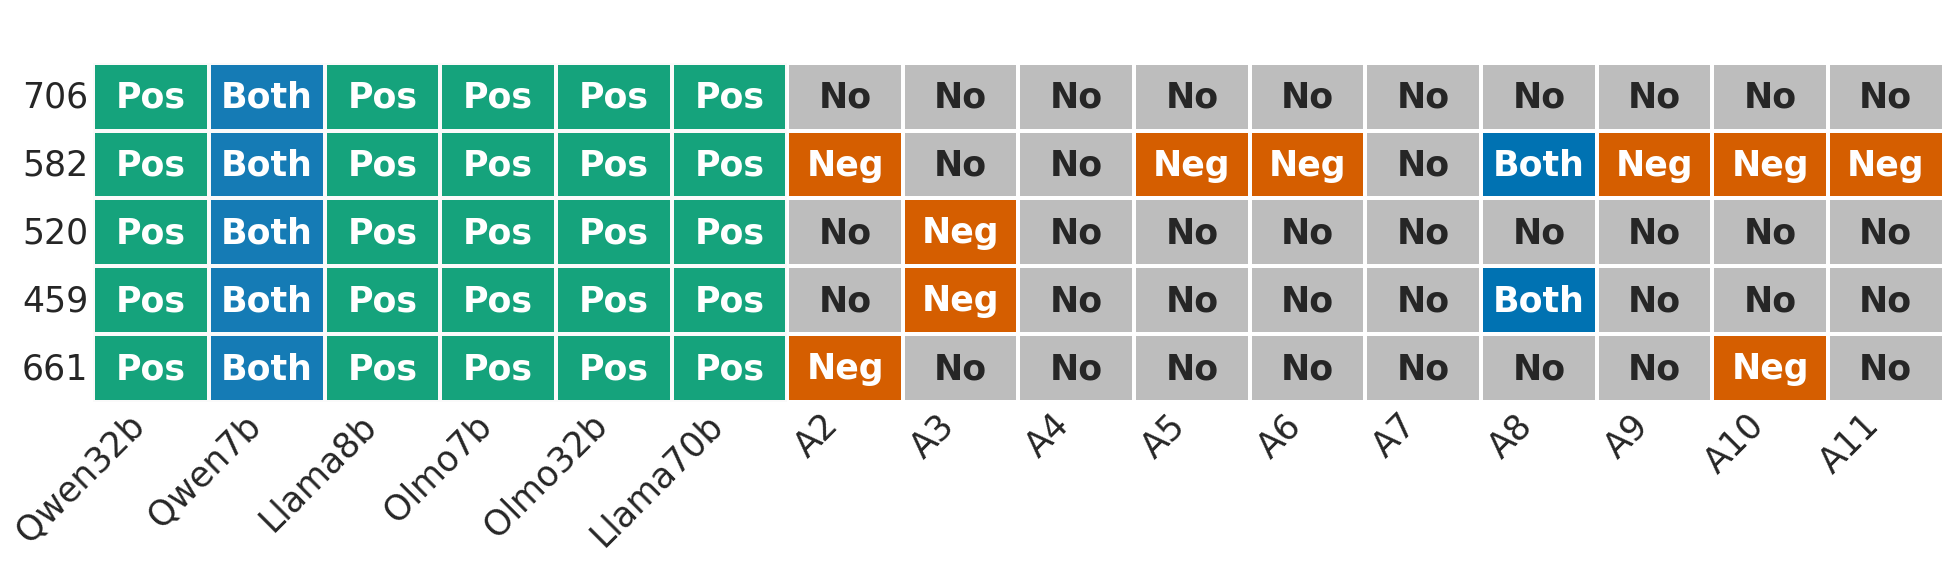

In [ ]:
# simplify labels
short_labels = {"No": "No", "Positive": "Pos", "Negative": "Neg", "Both": "Both"}
plot_df = extreme_cases_readable.copy()
for col in llm_final_cols + human_final_cols:
    plot_df[col] = plot_df[col].map(short_labels)

# count extreme cases
total_extreme_cases = plot_df.shape[0]
print(f"Total extreme cases (no human agrees with LLM mode): {total_extreme_cases}")

plot_top = plot_df.head(5)  # first 5 extreme cases
all_cols = llm_final_cols + human_final_cols

# Map to numeric for heatmap
label_to_num = {"No": 0, "Pos": 1, "Neg": 2, "Both": 3}
plot_numeric = plot_top[all_cols].replace(label_to_num)

# Colors for heatmap
palette = ["#BDBDBD", "#009E73", "#D55E00", "#0072B2"]

# clean x-tick labels
xtick_labels = [col.replace("_final_label", "").replace("_dual_interventions.md", "") for col in all_cols]


fig, ax = plt.subplots(figsize=(20, 6))

sns.heatmap(
    plot_numeric,
    annot=plot_top[all_cols],
    fmt='',
    cmap=sns.color_palette(palette),
    cbar=False,
    linewidths=1.5,
    linecolor='white',
    ax=ax,
    annot_kws={"fontsize": 25, "weight": "bold"}  # bigger annotation font
)


ax.set_xticks([i + 0.5 for i in range(len(all_cols))])
ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=25, weight='normal')
ax.set_yticks([i + 0.5 for i in range(len(plot_top))])
ax.set_yticklabels(plot_top.index, rotation=0, fontsize=25, weight='normal')
ax.set_title(" ", fontsize=24, pad=20, weight='bold')

for i in range(len(llm_final_cols)):
    ax.add_patch(plt.Rectangle((i, 0), 1, len(plot_top), color='lightgrey', alpha=0.1, lw=0))

ax.tick_params(length=0)

plt.tight_layout()
plt.show()

In [ ]:
# Select top extreme cases
plot_top = extreme_cases_readable.head(5)

# replace with your actual text column name
TEXT_COL = "discussion"

# Print each comment separately
for i, idx in enumerate(plot_top.index, start=1):

    print("\n" + "="*140)
    print(f"EXTREME CASE {i}")
    print(f"Index: {idx}")
    print("="*140)

    # original text
    print("\nTEXT:\n")
    print(all_annot.loc[idx, TEXT_COL])

    # LLM labels
    print("\nLLM LABELS:")
    print(plot_top.loc[idx, llm_final_cols].to_string())

    # Human labels
    print("\nHUMAN LABELS:")
    print(plot_top.loc[idx, human_final_cols].to_string())

    # agreement
    print("\nLLM AGREEMENT:")
    print(plot_top.loc[idx, "LLM_Agreement"])

    print("\n")


EXTREME CASE 1
Index: 706

TEXT:

User Hannah Rosin:
Or you could end up in a situation where it gets worse and worse and worse and the income-- you know, you have a sort of little upper class of people that these guys are talking about that consists of Bill Gates and maybe the people in this audience and not very many more people and everybody else is sort of struggling with the women holding the bag, it's called the last bag theory where the woman because she's raising the child is also going to school and making the money and the men are just sort of struggling and out of work.

User Dan Abrams:
I would just add to that, the bigger problem I think for men is the unwillingness to take what have been viewed as classically female jobs, teachers, nurses, or healthcare professionals, et cetera, and that's the area where if you want to talk about how do we make this better, how do we end-- how do we reverse men being finished, which they are-- how do we reverse that? Well, part of it has